# Membaca dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("air_pollution_hourly.csv")

# Inspeksi Dataset

In [3]:
df.head()

,timestamp,pm2_5_ug_m3,pm10_ug_m3,co_mg_m3,no2_ug_m3,so2_ug_m3,o3_ug_m3,temperature_c,humidity_pct
0,2025-01-01 00:00:00,14.9,24.1,0.312,8.3,3.1,11.3,24.5,89.7
1,2025-01-01 01:00:00,12.6,23.5,0.387,7.5,3.3,14.1,23.1,87.1
2,2025-01-01 02:00:00,14.2,24.1,0.280,7.8,3.4,19.8,24.0,91.3
3,2025-01-01 03:00:00,14.7,29.1,0.350,8.1,3.0,9.7,24.1,86.3
4,2025-01-01 04:00:00,15.1,20.3,0.363,8.1,3.9,15.3,22.1,92.2


In [4]:
df.shape

(8772, 9)

In [5]:
df.columns

Index(['timestamp', 'pm2_5_ug_m3', 'pm10_ug_m3', 'co_mg_m3', 'no2_ug_m3',
       'so2_ug_m3', 'o3_ug_m3', 'temperature_c', 'humidity_pct'],
      dtype='str')

In [6]:
# ini yang peting

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8772 entries, 0 to 8771
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      8772 non-null   str    
 1   pm2_5_ug_m3    8709 non-null   float64
 2   pm10_ug_m3     8705 non-null   float64
 3   co_mg_m3       8720 non-null   float64
 4   no2_ug_m3      8721 non-null   float64
 5   so2_ug_m3      8720 non-null   float64
 6   o3_ug_m3       8720 non-null   float64
 7   temperature_c  8708 non-null   float64
 8   humidity_pct   8707 non-null   float64
dtypes: float64(8), str(1)
memory usage: 616.9 KB


### df.shape memberi tahu: (jumlah_baris, jumlah_kolom) sedangkan df.info() menunjukkan tipe data dan jumlah nilai non-null.

In [7]:
# Ubah nama kolom
df.columns = ['timestamp', 'pm25', 'pm10', 'co', 'no2', 'so2', 'o3', 'temp', 'hum']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8772 entries, 0 to 8771
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  8772 non-null   str    
 1   pm25       8709 non-null   float64
 2   pm10       8705 non-null   float64
 3   co         8720 non-null   float64
 4   no2        8721 non-null   float64
 5   so2        8720 non-null   float64
 6   o3         8720 non-null   float64
 7   temp       8708 non-null   float64
 8   hum        8707 non-null   float64
dtypes: float64(8), str(1)
memory usage: 616.9 KB


# Ubah waktu

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8772 entries, 0 to 8771
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8772 non-null   datetime64[us]
 1   pm25       8709 non-null   float64       
 2   pm10       8705 non-null   float64       
 3   co         8720 non-null   float64       
 4   no2        8721 non-null   float64       
 5   so2        8720 non-null   float64       
 6   o3         8720 non-null   float64       
 7   temp       8708 non-null   float64       
 8   hum        8707 non-null   float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 616.9 KB


# Eksplor time series

In [11]:
# sisipkan hour, day, dan keterangan lainnya
df["hour"] = df["timestamp"].dt.hour

#df["day"] = df["timestamp"].dt.day
#df["month"] = df["timestamp"].dt.month
#df["day_of_week"] = df["timestamp"].dt.day_name()

In [12]:
df

,timestamp,pm25,pm10,co,no2,so2,o3,temp,hum,hour
0,2025-01-01 00:00:00,14.9,24.1,0.312,8.3,3.1,11.3,24.5,89.7,0
1,2025-01-01 01:00:00,12.6,23.5,0.387,7.5,3.3,14.1,23.1,87.1,1
2,2025-01-01 02:00:00,14.2,24.1,0.280,7.8,3.4,19.8,24.0,91.3,2
3,2025-01-01 03:00:00,14.7,29.1,0.350,8.1,3.0,9.7,24.1,86.3,3
4,2025-01-01 04:00:00,15.1,20.3,0.363,8.1,3.9,15.3,22.1,92.2,4
...,...,...,...,...,...,...,...,...,...,...
8767,2025-12-31 19:00:00,26.0,40.6,0.902,28.1,5.7,9.1,27.7,78.6,19
8768,2025-12-31 20:00:00,24.7,50.5,0.740,25.4,4.9,5.6,27.3,75.9,20
8769,2025-12-31 21:00:00,24.6,36.6,0.616,22.2,5.4,9.8,27.3,79.6,21
8770,2025-12-31 22:00:00,17.1,29.3,0.409,17.2,3.0,14.8,25.4,80.2,22


In [13]:
# sementara delete dulu kolom hour
df = df.drop("hour", axis=1)


In [14]:
df.head()

,timestamp,pm25,pm10,co,no2,so2,o3,temp,hum
0,2025-01-01 00:00:00,14.9,24.1,0.312,8.3,3.1,11.3,24.5,89.7
1,2025-01-01 01:00:00,12.6,23.5,0.387,7.5,3.3,14.1,23.1,87.1
2,2025-01-01 02:00:00,14.2,24.1,0.280,7.8,3.4,19.8,24.0,91.3
3,2025-01-01 03:00:00,14.7,29.1,0.350,8.1,3.0,9.7,24.1,86.3
4,2025-01-01 04:00:00,15.1,20.3,0.363,8.1,3.9,15.3,22.1,92.2


# Inspeksi statistik dasar

In [15]:
df.describe()

,timestamp,pm25,pm10,co,no2,so2,o3,temp,hum
count,8772,8709.000000,8705.000000,8720.000000,8721.000000,8720.000000,8720.000000,8708.000000,8707.000000
mean,2025-07-02 11:09:09.110807,22.496016,37.907191,0.532434,18.209024,4.423842,28.717729,26.996475,75.487711
min,2025-01-01 00:00:00,-12.000000,-25.000000,-1.500000,-8.000000,-5.000000,-10.000000,-20.000000,-15.000000
25%,2025-04-02 04:45:00,17.500000,30.100000,0.379000,12.300000,3.500000,14.900000,25.000000,69.000000
50%,2025-07-02 10:30:00,22.100000,37.200000,0.492000,16.700000,4.300000,21.400000,27.000000,75.500000
75%,2025-10-01 16:15:00,26.900000,44.700000,0.682000,23.900000,5.200000,44.500000,29.100000,82.000000
max,2025-12-31 23:00:00,999.000000,1500.000000,18.000000,600.000000,500.000000,900.000000,85.000000,135.000000
std,NaN,15.229671,22.506736,0.266520,9.548467,5.439971,19.578189,2.503727,8.179750


Mahasiswa akan menemukan beberapa nilai yang sengaja dimasukkan sebagai masalah.
Ini kesempatan bagus untuk memperkenalkan prinsip: Nilai ekstrem belum tentu salah. Nilai yang melanggar batas fisik jauh lebih kuat alasannya untuk dianggap invalid.

# Missing Values

In [16]:
df.isna().sum()

timestamp     0
pm25         63
pm10         67
co           52
no2          51
so2          52
o3           52
temp         64
hum          65
dtype: int64

In [17]:
# atau gunakan
df.isnull().sum()

timestamp     0
pm25         63
pm10         67
co           52
no2          51
so2          52
o3           52
temp         64
hum          65
dtype: int64

In [18]:
missing_percent = df.isnull().mean() * 100

In [19]:
print(missing_percent)

timestamp    0.000000
pm25         0.718194
pm10         0.763794
co           0.592795
no2          0.581395
so2          0.592795
o3           0.592795
temp         0.729594
hum          0.740994
dtype: float64


### Ini konsep penting:
### Jumlah missing ≠ tingkat keparahan missing
### Misalnya 50 missing dari 100 data sangat serius, tetapi 50 missing dari 1 juta data mungkin kecil.

In [20]:
import missingno as msno


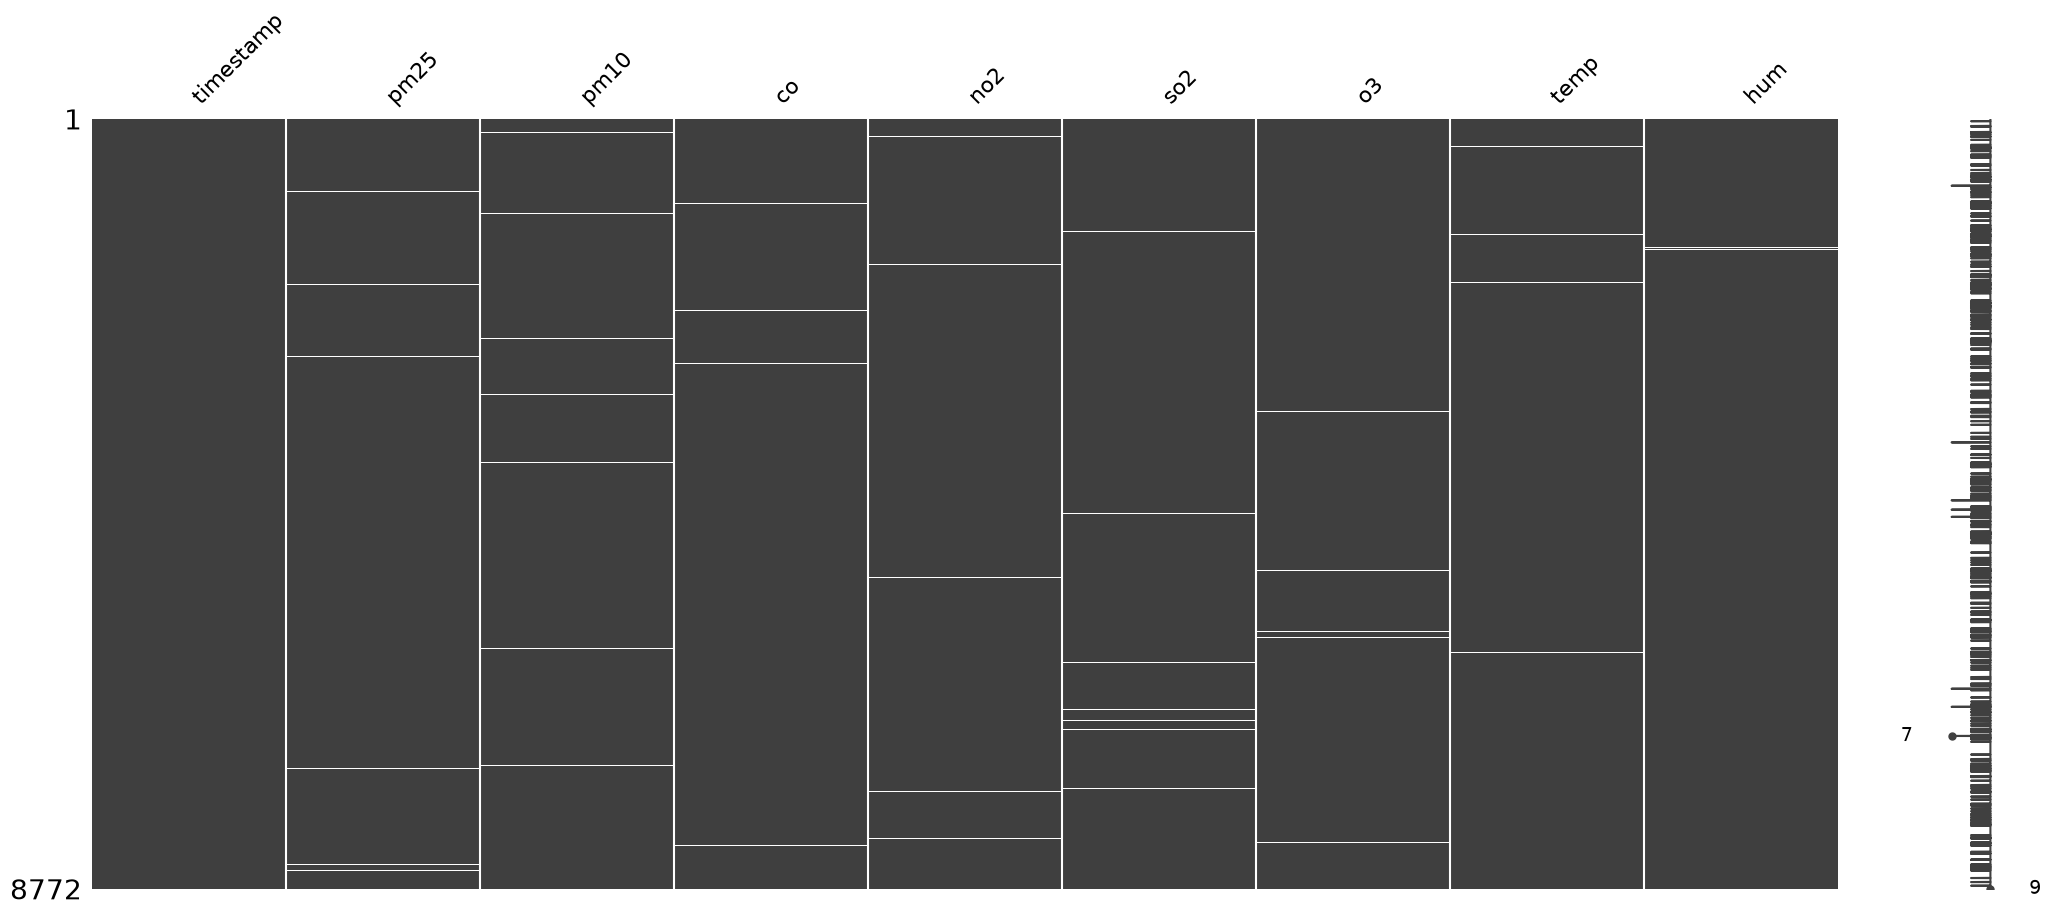

In [21]:
msno.matrix(df)
plt.show()

# Melihat baris yang memiliki missing value

In [22]:
df[df["pm25"].isnull()]

,timestamp,pm25,pm10,co,no2,so2,o3,temp,hum
151,2025-01-07 07:00:00,NaN,45.0,0.699,24.2,5.2,18.3,24.3,78.9
690,2025-01-29 18:00:00,NaN,48.2,0.837,26.0,6.5,14.0,29.3,73.3
762,2025-02-01 18:00:00,NaN,38.4,0.665,26.0,6.0,5.5,NaN,73.3
828,2025-02-04 12:00:00,NaN,21.7,0.360,12.1,3.9,54.5,30.0,72.1
844,2025-02-05 04:00:00,NaN,25.6,0.253,10.5,3.6,17.5,24.0,91.5
...,...,...,...,...,...,...,...,...,...
7887,2025-11-25 04:00:00,NaN,21.8,0.468,10.2,3.5,16.3,22.9,85.4
8190,2025-12-07 18:00:00,NaN,44.7,0.669,24.2,5.8,6.5,28.3,71.4
8494,2025-12-20 10:00:00,NaN,33.0,0.492,18.8,4.6,36.7,27.3,83.2
8509,2025-12-21 01:00:00,NaN,23.1,0.332,14.2,3.3,19.1,25.1,86.0


### Jangan langsung dropna()
Jadi mahasiswa perlu memahami bahwa: **missing value pada time-series adalah missing observation pada suatu waktu tertentu.**

# Fill dengan data valid terakhir
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html#pandas.DataFrame.ffill

In [23]:
df["pm25"] = df["pm25"].ffill()

In [24]:
# cek lagi
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8772 entries, 0 to 8771
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8772 non-null   datetime64[us]
 1   pm25       8772 non-null   float64       
 2   pm10       8705 non-null   float64       
 3   co         8720 non-null   float64       
 4   no2        8721 non-null   float64       
 5   so2        8720 non-null   float64       
 6   o3         8720 non-null   float64       
 7   temp       8708 non-null   float64       
 8   hum        8707 non-null   float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 616.9 KB


In [25]:
df["pm25"] = df["pm25"].ffill()

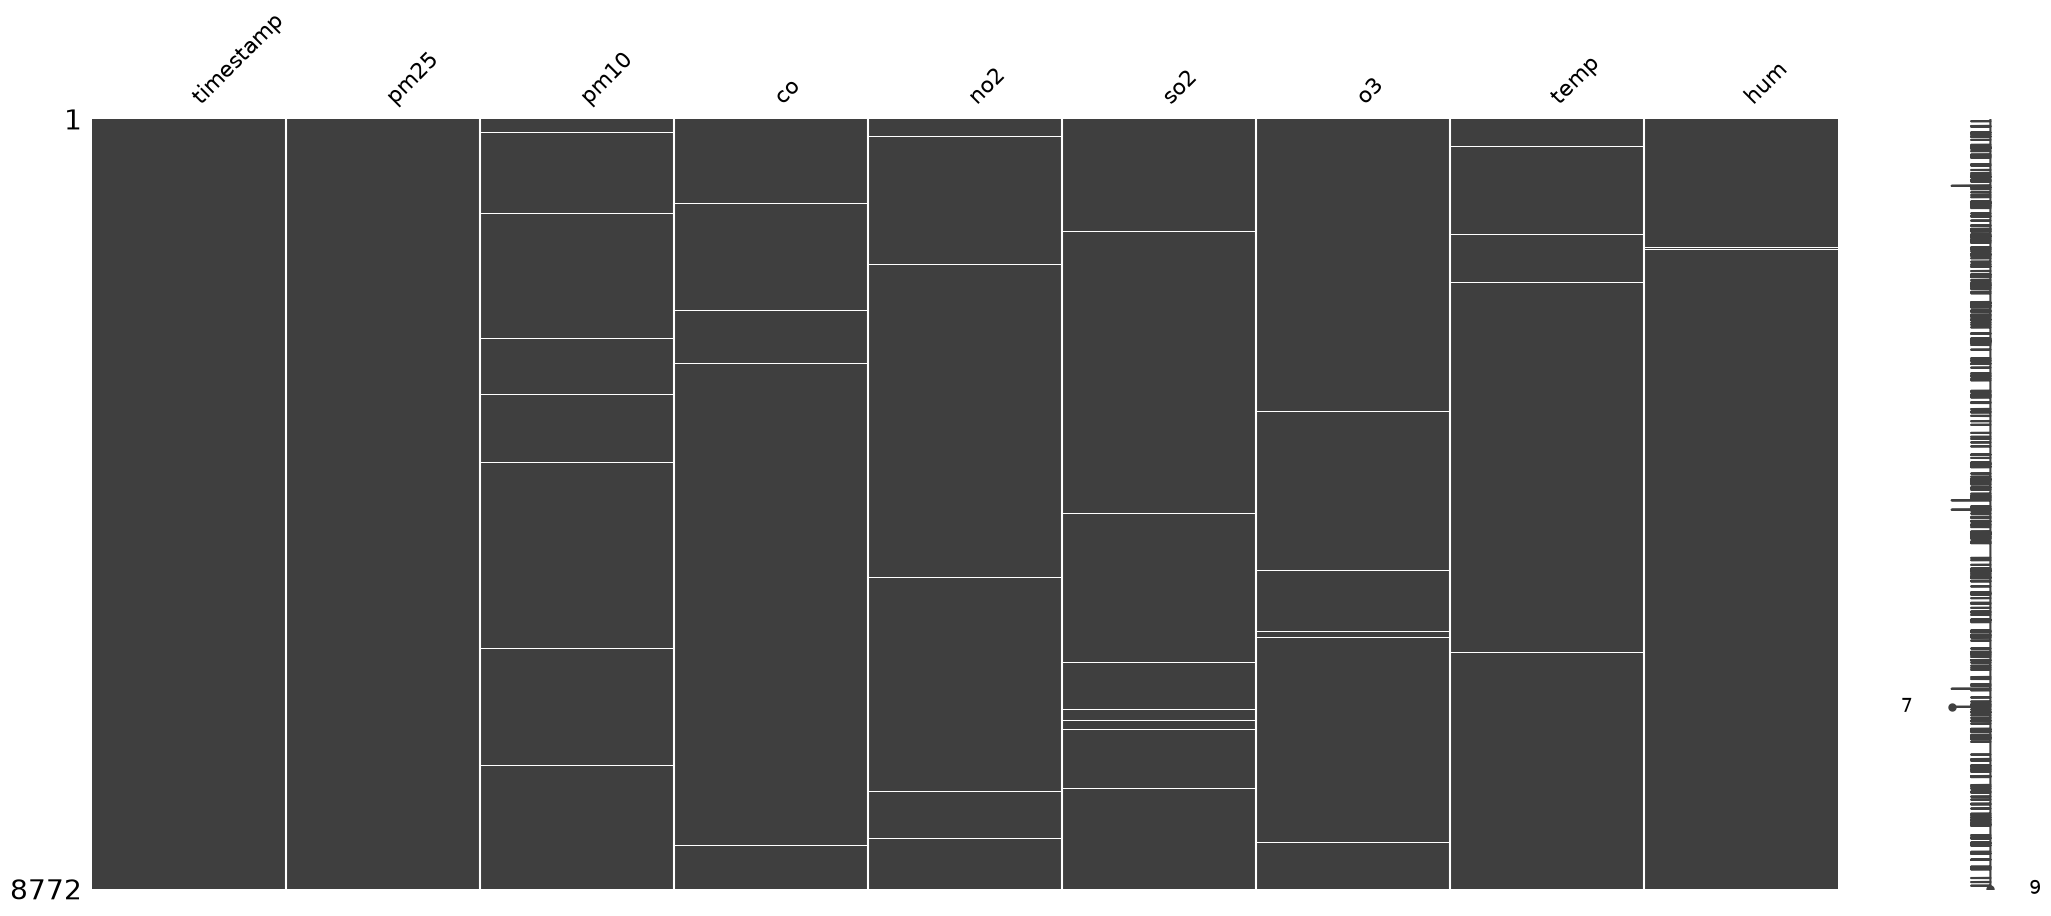

In [26]:
msno.matrix(df)
plt.show()

In [27]:
sensor_cols = [
    "pm25",
    "pm10",
    "co",
    "no2",#
    "so2",
    "o3",
    "temp",
    "hum"
]

df[sensor_cols] = df[sensor_cols].ffill()

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8772 entries, 0 to 8771
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8772 non-null   datetime64[us]
 1   pm25       8772 non-null   float64       
 2   pm10       8772 non-null   float64       
 3   co         8772 non-null   float64       
 4   no2        8772 non-null   float64       
 5   so2        8772 non-null   float64       
 6   o3         8772 non-null   float64       
 7   temp       8772 non-null   float64       
 8   hum        8772 non-null   float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 616.9 KB


### Tetapi hati-hati dengan ffill(). Ini bagian yang perlu diperhatikan. Bayangkan sensor mati selama 3 hari. Tidak masuk akal jika semua menggunakan data valid terakhir

In [29]:
### Gunakan pembatas:
df[sensor_cols] = df[sensor_cols].ffill(limit=3)

In [30]:
# cek lagi baris yang missing
df[df["pm25"].isnull()]

,timestamp,pm25,pm10,co,no2,so2,o3,temp,hum


# Alternatif: interpolasi

### Untuk temperature dan humidity, interpolasi sering menjadi eksperimen yang menarik.

In [31]:
df["temp"] = df["temp"].interpolate()

### ffill() → gunakan nilai valid sebelumnya

### bfill() → gunakan nilai valid berikutnya

### interpolate() → estimasi nilai di antara data

Jangan mengatakan salah satunya selalu terbaik. Strateginya tergantung karakteristik sensor dan durasi gap.

# Duplicate Timestamp

#### Karena time-series, kita sebaiknya memeriksa timestamp

In [32]:
print(df["timestamp"].duplicated().sum())

12


In [33]:
# cek dimana saja
df[df["timestamp"].duplicated(keep=False)]

,timestamp,pm25,pm10,co,no2,so2,o3,temp,hum
1092,2025-02-15 12:00:00,13.4,22.4,0.311,7.9,4.1,57.6,29.8,70.2
1093,2025-02-15 12:00:00,13.4,22.4,0.311,7.9,4.1,57.6,29.8,70.2
1468,2025-03-03 03:00:00,10.9,19.9,0.278,14.4,3.2,9.9,23.2,84.9
1469,2025-03-03 03:00:00,10.9,19.9,0.278,14.4,3.2,9.9,23.2,84.9
1834,2025-03-18 08:00:00,30.7,47.1,0.735,24.9,5.9,31.3,25.9,84.7
1835,2025-03-18 08:00:00,30.7,47.1,0.735,24.9,5.9,31.3,25.9,84.7
2170,2025-04-01 07:00:00,26.6,36.5,0.733,27.1,5.4,16.3,24.9,81.4
2171,2025-04-01 07:00:00,26.6,36.5,0.733,27.1,5.4,16.3,24.9,81.4
3637,2025-06-01 09:00:00,26.7,45.8,0.690,22.9,5.2,44.0,27.7,73.3
3638,2025-06-01 09:00:00,26.7,45.8,0.690,22.9,5.2,44.0,27.7,73.3


In [34]:
print(df["timestamp"].duplicated().sum())

12


In [35]:
# hapus duplicate, pertahankan record pertama
df = df.drop_duplicates(subset="timestamp", keep="first")

In [36]:
# urutkan kembali berdasarkan waktu
df = df.sort_values("timestamp").reset_index(drop=True)

In [37]:
print(df["timestamp"].duplicated().sum())

0


### Timestamp sama + seluruh nilai sama
→ sangat mungkin duplicate logging
→ drop_duplicates()

### Timestamp sama + nilai sensor berbeda
→ jangan langsung hapus
→ periksa konteks
→ mungkin agregasi dengan mean/median

# Mendeteksi nilai invalid

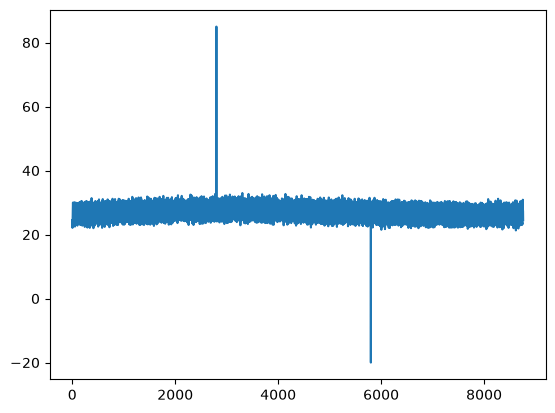

In [38]:
df["temp"].plot()
plt.show()

In [39]:
invalid_temp = ((df["temp"] < 10) |(df["temp"] > 45))
print(df[invalid_temp])

               timestamp  pm25  pm10     co   no2  so2    o3  temp   hum
2800 2025-04-27 16:00:00  22.8  35.6  0.417  15.8  3.8  39.2  85.0  70.4
5800 2025-08-30 16:00:00  30.9  43.8  0.544  20.1  4.9  37.1 -20.0  60.4


In [40]:
df.loc[invalid_temp, "temp"] = np.nan

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8760 non-null   datetime64[us]
 1   pm25       8760 non-null   float64       
 2   pm10       8760 non-null   float64       
 3   co         8760 non-null   float64       
 4   no2        8760 non-null   float64       
 5   so2        8760 non-null   float64       
 6   o3         8760 non-null   float64       
 7   temp       8758 non-null   float64       
 8   hum        8760 non-null   float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 616.1 KB


In [42]:
# Perbaiki, gunakan last valid data
df["temp"] = df["temp"].ffill(limit=3)

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8760 non-null   datetime64[us]
 1   pm25       8760 non-null   float64       
 2   pm10       8760 non-null   float64       
 3   co         8760 non-null   float64       
 4   no2        8760 non-null   float64       
 5   so2        8760 non-null   float64       
 6   o3         8760 non-null   float64       
 7   temp       8760 non-null   float64       
 8   hum        8760 non-null   float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 616.1 KB


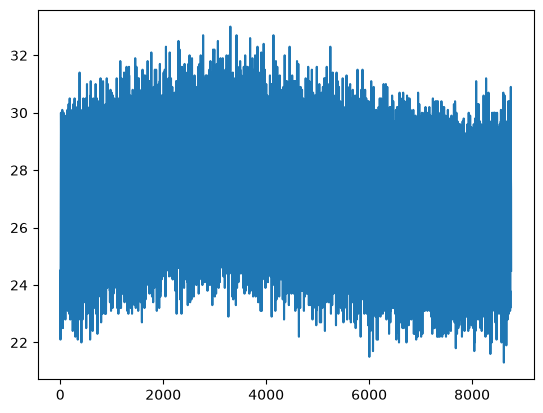

In [44]:
df["temp"].plot()
plt.show()

# TUGAS MAHASISWA
Lakukan hal yang sama untuk semua feature!

# Reusable Fungsi Cleaning Data Invalid

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8760 non-null   datetime64[us]
 1   pm25       8760 non-null   float64       
 2   pm10       8760 non-null   float64       
 3   co         8760 non-null   float64       
 4   no2        8760 non-null   float64       
 5   so2        8760 non-null   float64       
 6   o3         8760 non-null   float64       
 7   temp       8760 non-null   float64       
 8   hum        8760 non-null   float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 616.1 KB


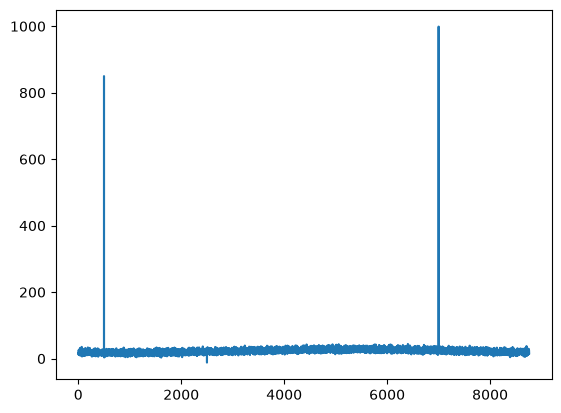

In [46]:
df["pm25"].plot()
plt.show()

In [47]:
def clean_range(df, column, minimum, maximum):
    invalid = (
        (df[column] < minimum) |
        (df[column] > maximum)
    )

    df.loc[invalid, column] = np.nan

    df[column] = df[column].ffill(limit=3)

    return df

In [48]:
df = clean_range(df, "pm25", 0, 500)
df = clean_range(df, "pm10", 0, 600)
df = clean_range(df, "co", 0, 10)
df = clean_range(df, "no2", 0, 400)
df = clean_range(df, "so2", 0, 300)
df = clean_range(df, "o3", 0, 500)
df = clean_range(df, "temp", 10, 45)
df = clean_range(df, "hum", 0, 100)


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8760 non-null   datetime64[us]
 1   pm25       8760 non-null   float64       
 2   pm10       8760 non-null   float64       
 3   co         8760 non-null   float64       
 4   no2        8760 non-null   float64       
 5   so2        8760 non-null   float64       
 6   o3         8760 non-null   float64       
 7   temp       8760 non-null   float64       
 8   hum        8760 non-null   float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 616.1 KB


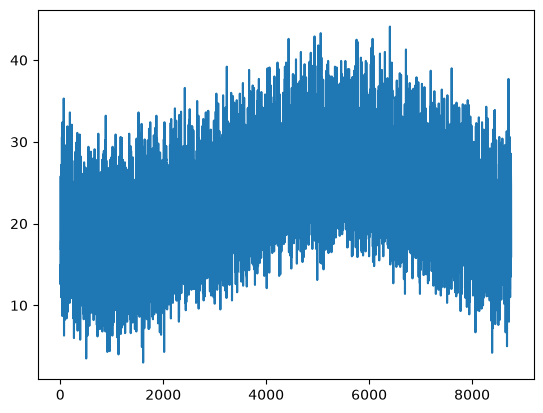

In [50]:
df["pm25"].plot()
plt.show()

# Cek Kembali

In [54]:
df.isnull().sum()

timestamp    0
pm25         0
pm10         0
co           0
no2          0
so2          0
o3           0
temp         0
hum          0
dtype: int64

In [55]:
df.describe()

,timestamp,pm25,pm10,co,no2,so2,o3,temp,hum
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2025-07-02 11:30:00,22.284292,37.600285,0.530818,18.137089,4.364817,28.645468,26.997237,75.500126
min,2025-01-01 00:00:00,3.000000,6.100000,0.076000,2.400000,0.400000,2.000000,21.300000,51.700000
25%,2025-04-02 05:45:00,17.500000,30.100000,0.379000,12.300000,3.500000,15.000000,25.000000,69.000000
50%,2025-07-02 11:30:00,22.100000,37.200000,0.492000,16.700000,4.300000,21.400000,27.000000,75.500000
75%,2025-10-01 17:15:00,26.800000,44.700000,0.682000,23.900000,5.200000,44.525000,29.100000,82.025000
max,2025-12-31 23:00:00,44.100000,71.200000,1.070000,43.200000,9.000000,72.500000,33.000000,97.500000
std,NaN,6.604891,10.259614,0.188687,7.234234,1.188989,17.203710,2.373048,8.107642


# Scaling
### Setelah data dianggap bersih, baru kita masuk ke scaling.

In [56]:
# Pisahkan Feature

features = [
    "pm25",
    "pm10",
    "co",
    "no2",
    "so2",
    "o3",
    "temp",
    "hum"
]

X = df[features]

In [57]:
X.describe()

,pm25,pm10,co,no2,so2,o3,temp,hum
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,22.284292,37.600285,0.530818,18.137089,4.364817,28.645468,26.997237,75.500126
std,6.604891,10.259614,0.188687,7.234234,1.188989,17.203710,2.373048,8.107642
min,3.000000,6.100000,0.076000,2.400000,0.400000,2.000000,21.300000,51.700000
25%,17.500000,30.100000,0.379000,12.300000,3.500000,15.000000,25.000000,69.000000
50%,22.100000,37.200000,0.492000,16.700000,4.300000,21.400000,27.000000,75.500000
75%,26.800000,44.700000,0.682000,23.900000,5.200000,44.525000,29.100000,82.025000
max,44.100000,71.200000,1.070000,43.200000,9.000000,72.500000,33.000000,97.500000


## StandardScaler
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

| Kondisi | Lebih cocok |
|---|---|
| Feature punya satuan dan skala sangat berbeda | Keduanya bisa |
| Ingin data berpusat di sekitar 0 | StandardScaler |
| Ingin rentang tetap 0–1 | MinMaxScaler |
| Algoritma sensitif terhadap jarak, misalnya KNN | Keduanya bisa |
| SVM, Logistic Regression, Neural Network | Sering StandardScaler |
| Input neural network tertentu yang diinginkan 0–1 | MinMaxScaler |
| Ada outlier kuat | Keduanya bisa terdampak, MinMax biasanya lebih sensitif |
| Data relatif mendekati distribusi normal | StandardScaler sering lebih natural |

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [60]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

In [61]:
X_scaled.head()

,pm25,pm10,co,no2,so2,o3,temp,hum
0,-1.118068,-1.315942,-1.159756,-1.359875,-1.063836,-1.008298,-1.052393,1.751518
1,-1.466314,-1.374427,-0.762249,-1.470466,-0.895616,-0.845533,-1.642386,1.430815
2,-1.224056,-1.315942,-1.329359,-1.428994,-0.811506,-0.514190,-1.263105,1.948874
3,-1.148350,-0.828566,-0.958352,-1.387523,-1.147946,-1.101306,-1.220963,1.332137
4,-1.087785,-1.686347,-0.889451,-1.387523,-0.390957,-0.775776,-2.063809,2.059887


# Tetapi untuk Machine Learning nanti: split dahulu

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    shuffle=False
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)